# Поток сигналов: от raw до submitted

Sankey-диаграмма attrition:
1. Raw signals (per cycle)
2. PER_TICKER_POLICY filter (DISABLED dropped)
3. counter_bias_guard
4. Tier classification (TIER1/2/3/NONE)
5. Meta classifier
6. Risk Manager
7. Submitted

**Цель:** определить узкие места и предложить конкретные изменения порогов для роста submitted.

In [1]:
from __future__ import annotations
import json, re, sqlite3, os, sys
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except Exception:
    HAS_PLOTLY = False

ROOT = Path('/Users/smokkkkiiii/Documents/MoexML/release_moex_ml')
LOG_PATH = Path('/tmp/pod_logs_1340.txt')
DECISIONS_DB = ROOT / 'data' / 'decisions.db'
TRADES_DB = ROOT / 'data' / 'trades.db'
CONFIG_PY = ROOT / 'app' / 'config.py'

assert LOG_PATH.exists(), f'log file missing: {LOG_PATH}'
assert DECISIONS_DB.exists(), f'decisions db missing: {DECISIONS_DB}'

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 50)
print('plotly available:', HAS_PLOTLY)

plotly available: True


## 1. Parse pod logs — pull per-cycle attrition + metrics_snapshot timeline

In [2]:
raw_lines = LOG_PATH.read_text().splitlines()
print(f'log lines: {len(raw_lines):,}')

def _json_tail(line: str) -> dict | None:
    m = re.search(r'\{.*\}$', line)
    if not m:
        return None
    try:
        return json.loads(m.group(0))
    except Exception:
        return None

cycles = []   # per-cycle dispatcher attrition (the truth source)
snapshots = []  # cumulative metrics_snapshot
per_ticker_filter = []  # PER_TICKER_POLICY drops
tier_assigned = []  # downstream tier classifier outcomes

for ln in raw_lines:
    if 'Dispatcher cycle attrition' in ln:
        j = _json_tail(ln)
        if j:
            cycles.append(j)
    elif '"metrics_snapshot"' in ln:
        j = _json_tail(ln)
        if j and 'metrics' in j:
            snapshots.append(j['metrics'])
    elif 'Signals filtered by PER_TICKER_POLICY' in ln:
        j = _json_tail(ln)
        if j:
            per_ticker_filter.append(j)
    elif '"msg":"Tier assigned"' in ln or '"msg": "Tier assigned"' in ln:
        j = _json_tail(ln)
        if j:
            tier_assigned.append(j)

print(f'cycle attrition records  : {len(cycles)}')
print(f'metrics_snapshot records : {len(snapshots)}')
print(f'PER_TICKER filter records: {len(per_ticker_filter)}')
print(f'Tier assigned records    : {len(tier_assigned)}')

log lines: 2,000
cycle attrition records  : 17
metrics_snapshot records : 52
PER_TICKER filter records: 21
Tier assigned records    : 30


In [3]:
# Flatten cycles into a dataframe
rows = []
for c in cycles:
    a = c.get('attrition', {})
    rej = c.get('rejections', {})
    lat = c.get('latencies_ms', {})
    rows.append({
        'ts': c.get('ts'),
        'cycle_id': c.get('cycle_id'),
        'raw': a.get('raw', 0),
        'allowed': a.get('allowed', 0),
        'tier_passed': a.get('tier_passed', 0),
        'meta_passed': a.get('meta_passed', 0),
        'risk_passed': a.get('risk_passed', 0),
        'submitted': a.get('submitted', 0),
        'rej_no_trade': rej.get('no_trade', 0),
        'rej_veto': rej.get('veto', 0),
        'rej_safe_mode': rej.get('safe_mode', 0),
        'rej_daily_cap': rej.get('daily_trade_soft_cap', 0),
        'rej_risk_cash': rej.get('risk_rejected_cash_reserve', 0),
        'rej_late_stage': rej.get('late_stage_check', 0),
        'gather_ms': lat.get('gather', 0),
        'aggregate_ms': lat.get('aggregate', 0),
    })
cycles_df = pd.DataFrame(rows)
cycles_df['ts'] = pd.to_datetime(cycles_df['ts'], errors='coerce', utc=True)
cycles_df = cycles_df.sort_values('ts').reset_index(drop=True)
cycles_df.head()

,ts,cycle_id,raw,allowed,tier_passed,meta_passed,risk_passed,submitted,rej_no_trade,rej_veto,rej_safe_mode,rej_daily_cap,rej_risk_cash,rej_late_stage,gather_ms,aggregate_ms
0,2026-05-27 10:12:29.509517+00:00,c3894ac8,41,15,0,0,0,0,4,1,0,0,0,0,4991,0
1,2026-05-27 10:12:57.063537+00:00,c3894ac9,5,3,0,0,0,0,3,0,0,0,0,0,2644,1
2,2026-05-27 10:13:02.204018+00:00,c3894ac9,5,2,0,0,0,0,2,0,0,0,0,0,2604,1
3,2026-05-27 10:14:02.545855+00:00,c3894acb,5,1,0,0,0,0,1,0,0,0,0,0,2949,1
4,2026-05-27 10:14:32.561124+00:00,c3894acc,5,4,0,0,0,0,2,0,0,0,0,0,2963,0


In [4]:
# Per-cycle funnel totals (last 24h of logs)
funnel_totals = cycles_df[['raw','allowed','tier_passed','meta_passed','risk_passed','submitted']].sum().to_dict()
print('CUMULATIVE FUNNEL across captured cycles:')
for k,v in funnel_totals.items():
    print(f'  {k:<14} = {v}')

# Pick the latest *non-empty* metrics_snapshot — the very last log line may be
# a shutdown row where signal_attrition has reset to zero.
def _latest_nonempty(snaps):
    for s in reversed(snaps):
        sa = s.get('signal_attrition', {})
        if sa and int(sa.get('raw', 0)) > 0:
            return s
    return snaps[-1] if snaps else {}

if snapshots:
    latest = _latest_nonempty(snapshots)
    sa = latest.get('signal_attrition', {})
    print('\nLatest non-empty metrics_snapshot.signal_attrition (lifetime totals):')
    for k,v in sa.items():
        print(f'  {k:<10} = {v}')
    print('  rejections :', latest.get('decision_rejection_breakdown'))
    print('  timestamp  :', latest.get('ts_utc'))
else:
    latest = {}

CUMULATIVE FUNNEL across captured cycles:
  raw            = 121
  allowed        = 46
  tier_passed    = 0
  meta_passed    = 0
  risk_passed    = 0
  submitted      = 0

Latest non-empty metrics_snapshot.signal_attrition (lifetime totals):
  raw        = 41
  allowed    = 15
  tier       = 0
  meta       = 0
  risk       = 0
  submitted  = 0
  rejections : {'no_trade': 4, 'veto': 1}
  timestamp  : 2026-05-27T10:12:54.085930+00:00


## 2. Funnel visualization — stacked bar + Sankey

We use the lifetime totals from the **latest `metrics_snapshot`** because (a) it covers more cycles than the 17 we caught in the trailing log buffer and (b) the metrics writer is the canonical Grafana source.

In [5]:
# Build a canonical 7-stage funnel using a robust mixed source:
# 1) raw -> allowed from logs (the per-cycle PER_TICKER_POLICY drops are explicit)
# 2) allowed -> aggregator outcome (rejections.no_trade + rejections.veto) from logs
# 3) tier_passed / meta_passed / risk_passed / submitted from logs

# Use the *non-empty* latest snapshot (computed above); fall back to cycle totals.
live_sa = latest.get('signal_attrition', {}) if isinstance(latest, dict) else {}
live_rej = latest.get('decision_rejection_breakdown', {}) if isinstance(latest, dict) else {}

# normalize key names — the metrics writer uses short names (tier/meta/risk)
raw         = int(live_sa.get('raw',       funnel_totals['raw']) or funnel_totals['raw'])
allowed     = int(live_sa.get('allowed',   funnel_totals['allowed']) or funnel_totals['allowed'])
tier_passed = int(live_sa.get('tier',      live_sa.get('tier_passed', funnel_totals['tier_passed'])) or funnel_totals['tier_passed'])
meta_passed = int(live_sa.get('meta',      live_sa.get('meta_passed', funnel_totals['meta_passed'])) or funnel_totals['meta_passed'])
risk_passed = int(live_sa.get('risk',      live_sa.get('risk_passed', funnel_totals['risk_passed'])) or funnel_totals['risk_passed'])
submitted   = int(live_sa.get('submitted', funnel_totals['submitted']) or funnel_totals['submitted'])

no_trade      = int(live_rej.get('no_trade', 0) or 0)
veto          = int(live_rej.get('veto', 0) or 0)
risk_rej_cash = int(live_rej.get('risk_rejected_cash_reserve', 0) or 0)
safe_mode     = int(live_rej.get('safe_mode', 0) or 0)
daily_cap     = int(live_rej.get('daily_trade_soft_cap', 0) or 0)
late_stage    = int(live_rej.get('late_stage_check', 0) or 0)

# aggregator stage = allowed - (no_trade + veto)
agg_survived = max(0, allowed - no_trade - veto)

stages = [
    ('raw',                raw),
    ('after_PER_TICKER',   allowed),
    ('after_aggregator',   agg_survived),
    ('tier_passed',        tier_passed),
    ('meta_passed',        meta_passed),
    ('risk_passed',        risk_passed),
    ('submitted',          submitted),
]
labels, counts = zip(*stages)
drops    = [counts[i-1]-counts[i] if i>0 else 0 for i in range(len(counts))]
drop_pct = [(d/counts[i-1]*100 if counts[i-1] else 0.0) for i,d in enumerate(drops)]

funnel = pd.DataFrame({
    'stage': labels,
    'survivors': counts,
    'dropped_in_stage': drops,
    'drop_pct': drop_pct,
})
print('Funnel snapshot (lifetime totals from latest non-empty metrics_snapshot):')
print(funnel.to_string(index=False))
funnel

Funnel snapshot (lifetime totals from latest non-empty metrics_snapshot):
           stage  survivors  dropped_in_stage   drop_pct
             raw         41                 0   0.000000
after_PER_TICKER         15                26  63.414634
after_aggregator         10                 5  33.333333
     tier_passed          0                10 100.000000
     meta_passed          0                 0   0.000000
     risk_passed          0                 0   0.000000
       submitted          0                 0   0.000000


,stage,survivors,dropped_in_stage,drop_pct
0,raw,41,0,0.000000
1,after_PER_TICKER,15,26,63.414634
2,after_aggregator,10,5,33.333333
3,tier_passed,0,10,100.000000
4,meta_passed,0,0,0.000000
5,risk_passed,0,0,0.000000
6,submitted,0,0,0.000000


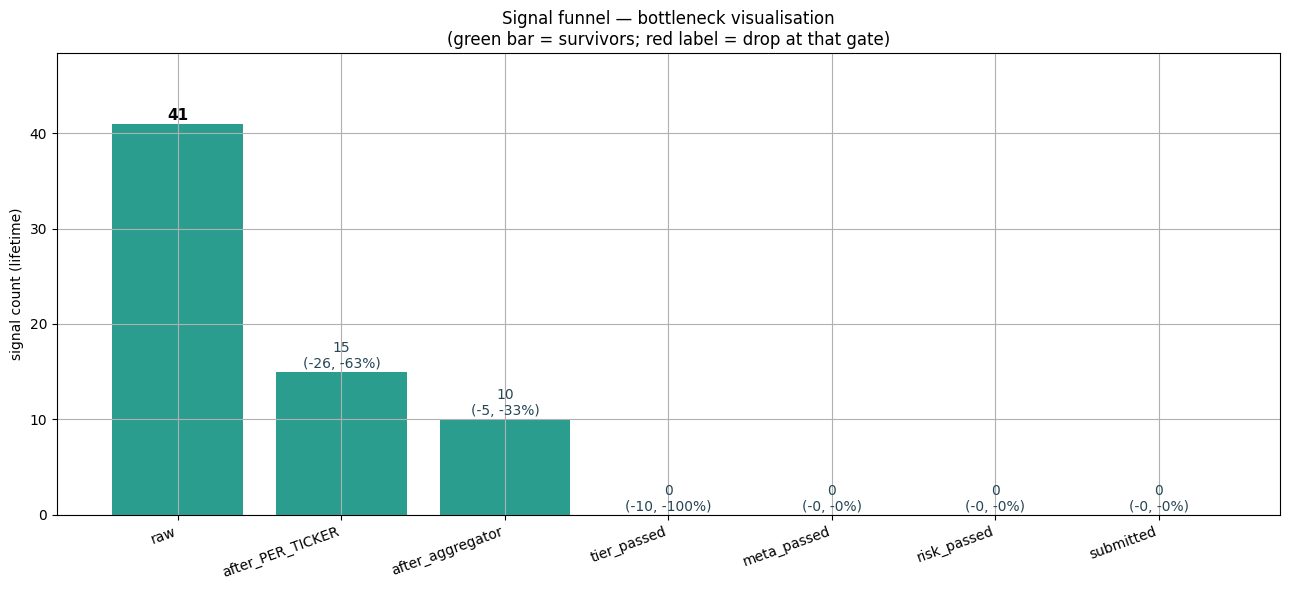

In [6]:
# Stacked bar — survivors vs cumulative loss
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(labels))
ax.bar(x, counts, color='#2a9d8f', label='survivors')
for i,(c,d) in enumerate(zip(counts, drops)):
    if i==0:
        ax.text(i, c+raw*0.01, f'{c}', ha='center', fontsize=11, fontweight='bold')
    else:
        ax.text(i, c+raw*0.01, f'{c}\n(-{d}, -{drop_pct[i]:.0f}%)', ha='center', fontsize=10, color='#264653')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('signal count (lifetime)')
ax.set_title('Signal funnel — bottleneck visualisation\n(green bar = survivors; red label = drop at that gate)')
ax.set_ylim(0, max(counts)*1.18 if max(counts)>0 else 1)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'B_funnel_bar.png', dpi=110, bbox_inches='tight')
plt.show()

In [7]:
# Sankey diagram (plotly) - if available
if HAS_PLOTLY and raw > 0:
    # Sankey nodes:
    # 0 raw
    # 1 allowed
    # 2 PER_TICKER_DROP
    # 3 aggregator_survived
    # 4 no_trade
    # 5 veto
    # 6 tier_passed
    # 7 tier_dropped
    # 8 meta_passed
    # 9 meta_dropped
    #10 risk_passed
    #11 risk_dropped (incl. cash reserve)
    #12 submitted
    #13 late_stage_dropped
    node_labels = [
        f'raw ({raw})',
        f'allowed ({allowed})',
        f'PER_TICKER drop ({raw-allowed})',
        f'aggregator OK ({agg_survived})',
        f'no_trade ({no_trade})',
        f'veto ({veto})',
        f'tier_passed ({tier_passed})',
        f'tier_dropped ({agg_survived-tier_passed})',
        f'meta_passed ({meta_passed})',
        f'meta_dropped ({tier_passed-meta_passed})',
        f'risk_passed ({risk_passed})',
        f'risk_rejected ({meta_passed-risk_passed}) +cash {risk_rej_cash}',
        f'submitted ({submitted})',
        f'late_stage/safe_mode dropped ({risk_passed-submitted})',
    ]
    sankey_src   = [0,0, 1,1,1, 3,3, 6,6, 8,8, 10,10]
    sankey_tgt   = [1,2, 3,4,5, 6,7, 8,9, 10,11, 12,13]
    sankey_val   = [
        max(allowed,0), max(raw-allowed,0),
        max(agg_survived,0), max(no_trade,0), max(veto,0),
        max(tier_passed,0), max(agg_survived-tier_passed,0),
        max(meta_passed,0), max(tier_passed-meta_passed,0),
        max(risk_passed,0), max(meta_passed-risk_passed,0),
        max(submitted,0), max(risk_passed-submitted,0),
    ]
    colors = ['#264653','#e76f51','#2a9d8f','#e76f51','#e76f51','#2a9d8f','#e76f51','#2a9d8f','#e76f51','#2a9d8f','#e76f51','#2a9d8f','#e76f51']
    fig = go.Figure(go.Sankey(
        node=dict(label=node_labels, pad=18, thickness=18),
        link=dict(source=sankey_src, target=sankey_tgt, value=sankey_val, color=colors)
    ))
    fig.update_layout(title='Signal funnel — Sankey (raw → submitted)', font_size=11, height=600)
    fig.show()
else:
    print('plotly not available — skipping Sankey (PNG bar chart already saved)')

## 3. Where do signals die? Stage-by-stage diagnostics

### Stage 1 — PER_TICKER_POLICY (raw → allowed)

In [8]:
# Pull current PER_TICKER_POLICY from config.py via regex so the notebook is self-contained
cfg_src = CONFIG_PY.read_text()
m = re.search(r'PER_TICKER_POLICY:\s*dict\[str,\s*str\]\s*=\s*\{([^}]+)\}', cfg_src, re.DOTALL)
policy_map = {}
if m:
    body = m.group(1)
    for line in body.splitlines():
        line = line.strip().rstrip(',')
        if not line or line.startswith('#'):
            continue
        parts = re.match(r'"([^\"]+)"\s*:\s*"([^\"]+)"', line)
        if parts:
            policy_map[parts.group(1)] = parts.group(2)
policy_df = pd.DataFrame(sorted(policy_map.items()), columns=['ticker','policy'])
policy_counts = policy_df['policy'].value_counts()
print('Current PER_TICKER_POLICY distribution:')
print(policy_counts)
print(f'\nTotal tickers in policy : {len(policy_df)}')
print(f'GOLD                    : {(policy_df["policy"]=="GOLD").sum()}')
print(f'WHITELIST_ONLY          : {(policy_df["policy"]=="WHITELIST_ONLY").sum()}')
print(f'DISABLED                : {(policy_df["policy"]=="DISABLED").sum()}')
policy_df

Current PER_TICKER_POLICY distribution:
policy
DISABLED          14
GOLD               5
WHITELIST_ONLY     1
Name: count, dtype: int64

Total tickers in policy : 20
GOLD                    : 5
WHITELIST_ONLY          : 1
DISABLED                : 14


,ticker,policy
0,AFLT,DISABLED
1,ALRS,DISABLED
2,CHMF,GOLD
3,GAZP,GOLD
4,GMKN,DISABLED
5,LKOH,DISABLED
6,MGNT,GOLD
7,MOEX,DISABLED
8,MTSS,DISABLED
9,NLMK,DISABLED


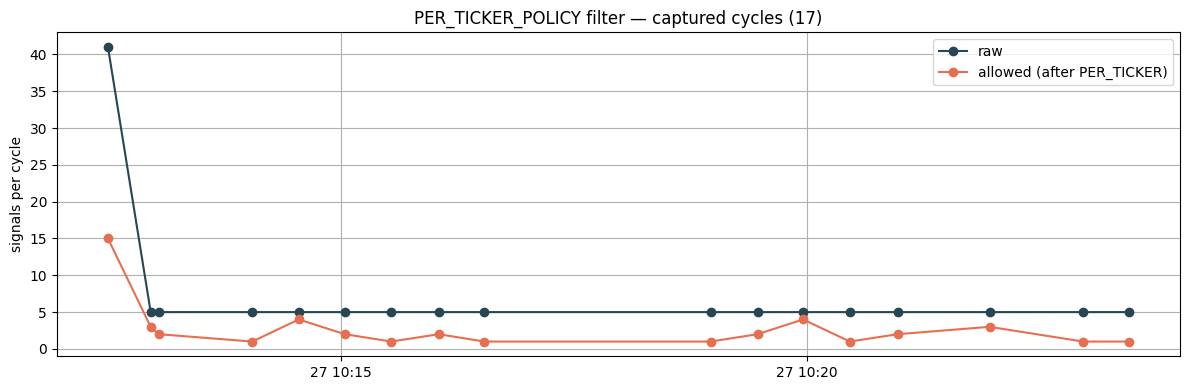


PER_TICKER allow rate: 15/41 = 36.6%  (loses 63.4%)

DISABLED tickers: 14/20  (70% of the universe)
DISABLED list:
AFLT, ALRS, GMKN, LKOH, MOEX, MTSS, NLMK, NVTK, PLZL, ROSN, T, VTBR, X5, YDEX


In [9]:
# Visualise allow-rate per cycle
if len(cycles_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(cycles_df['ts'], cycles_df['raw'], '-o', color='#264653', label='raw')
    ax.plot(cycles_df['ts'], cycles_df['allowed'], '-o', color='#e76f51', label='allowed (after PER_TICKER)')
    ax.set_title(f'PER_TICKER_POLICY filter — captured cycles ({len(cycles_df)})')
    ax.set_ylabel('signals per cycle')
    ax.legend()
    plt.tight_layout(); plt.show()

# allow rate
if raw > 0:
    print(f'\nPER_TICKER allow rate: {allowed}/{raw} = {allowed/raw*100:.1f}%  (loses {(raw-allowed)/raw*100:.1f}%)')

# from policy distribution we infer how many tickers contribute to the drop
n_disabled = (policy_df['policy']=='DISABLED').sum()
n_total = len(policy_df)
print(f'\nDISABLED tickers: {n_disabled}/{n_total}  ({n_disabled/n_total*100:.0f}% of the universe)')
print('DISABLED list:')
print(', '.join(policy_df.loc[policy_df['policy']=="DISABLED", 'ticker'].tolist()))

### Stage 2 — Aggregator (allowed → tier_passed)

This is the **critical** stage in production. The aggregator can downgrade a decision to `NO_TRADE` for several reasons before tier classification ever runs:
- `all neutral` — no BUY/SELL signals survive direction voting.
- `COUNTER_BIAS` — proposed direction contradicts the per-ticker direction bias (Phase 28.E guard).
- `PRE_LONG_FALLING_KNIFE` — last 30-min momentum below `PRE_LONG_MIN_MOMENTUM_PCT` (default −1.5 %).
- `anomaly veto` — confluence-mode anomaly verify says opposite.
- `MTF counter-trend VETO` — multi-timeframe trends point against the trade.
- conflict-resolver tie.

In [10]:
# Count rationales seen in logs — search the raw log lines for keywords
agg_reasons = Counter()
for ln in raw_lines:
    if 'COUNTER_BIAS' in ln:
        agg_reasons['COUNTER_BIAS'] += 1
    if 'all neutral' in ln:
        agg_reasons['all_neutral'] += 1
    if 'PRE_LONG_FALLING_KNIFE' in ln:
        agg_reasons['PRE_LONG_FALLING_KNIFE'] += 1
    if 'MTF counter-trend VETO' in ln:
        agg_reasons['MTF_counter_trend_VETO'] += 1
    if 'anomaly veto' in ln:
        agg_reasons['anomaly_veto'] += 1
    if 'session_floor' in ln:
        agg_reasons['session_floor'] += 1
agg_reasons_df = pd.DataFrame(sorted(agg_reasons.items(), key=lambda x: -x[1]), columns=['reason','count'])
print('Aggregator-stage rejection reasons (log scan):')
print(agg_reasons_df.to_string(index=False))

# also: how many "Tier assigned" lines show tier=NONE vs tier!=NONE
tier_none = sum(1 for j in tier_assigned if j.get('tier') == 'NONE' or j.get('action') == 'NO_TRADE')
tier_real = len(tier_assigned) - tier_none
print(f'\nTier assigned events: {len(tier_assigned)} total -> NONE/NO_TRADE: {tier_none}, real tier: {tier_real}')
tier_pass_rate = tier_real/len(tier_assigned)*100 if tier_assigned else 0.0
print(f'Tier pass-rate (of decisions that even reach the classifier): {tier_pass_rate:.1f}%')

Aggregator-stage rejection reasons (log scan):
     reason  count
all_neutral     42

Tier assigned events: 30 total -> NONE/NO_TRADE: 30, real tier: 0
Tier pass-rate (of decisions that even reach the classifier): 0.0%


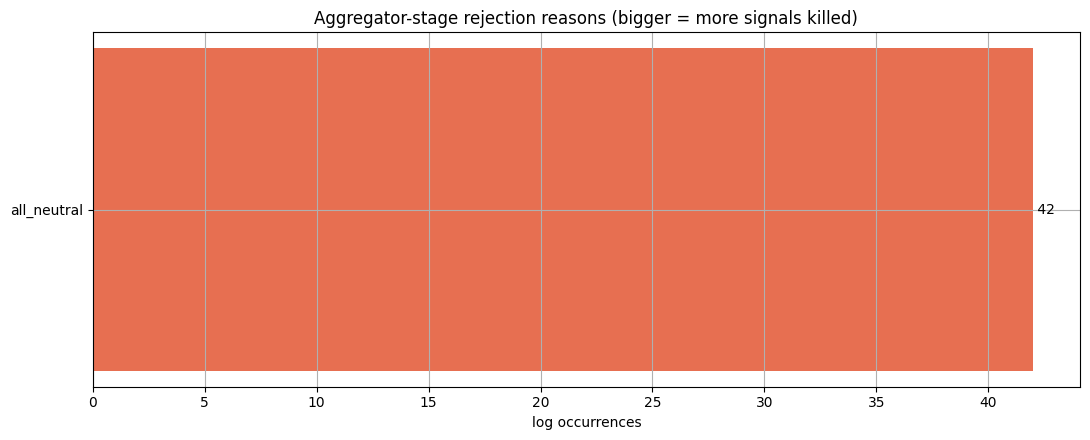

In [11]:
if not agg_reasons_df.empty:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.barh(agg_reasons_df['reason'], agg_reasons_df['count'], color='#e76f51')
    ax.set_xlabel('log occurrences')
    ax.set_title('Aggregator-stage rejection reasons (bigger = more signals killed)')
    ax.invert_yaxis()
    for i,v in enumerate(agg_reasons_df['count']):
        ax.text(v, i, f' {v}', va='center')
    plt.tight_layout(); plt.show()

### Stage 3 — Tier classifier (allowed → tier_passed)
Even when a decision survives the aggregator, it can still be killed when `combined_magnitude` is below `TIER{1,2,3}_MIN_MAGNITUDE` and `expected_rr` is below the matching `_MIN_RR`.

In [12]:
# Parse the current tier thresholds from config.py
def _scan_const(name: str) -> float | None:
    m = re.search(rf'^\s*{name}\s*=\s*([0-9]*\.?[0-9]+)', cfg_src, re.MULTILINE)
    return float(m.group(1)) if m else None
thr = {k: _scan_const(k) for k in [
    'TIER1_MIN_MAGNITUDE','TIER1_MIN_RR',
    'TIER2_MIN_MAGNITUDE','TIER2_MIN_RR',
    'TIER3_MIN_MAGNITUDE','TIER3_MIN_RR',
    'META_MIN_PROBA',
]}
thr_df = pd.DataFrame([(k,v) for k,v in thr.items()], columns=['threshold','value'])
print('Tier / meta thresholds in current build:')
print(thr_df.to_string(index=False))

# Sample what magnitudes/RR the recent decisions actually have
conn = sqlite3.connect(DECISIONS_DB)
dec_df = pd.read_sql('SELECT ticker, action, tier, combined_magnitude, signals_json, rationale, created_at FROM decisions ORDER BY created_at DESC LIMIT 200', conn)
conn.close()
print(f'\ndecisions persisted: {len(dec_df)}')
print(dec_df[['ticker','action','tier','combined_magnitude']].head(8).to_string(index=False))
print(f'\nDistribution of combined_magnitude:')
print(dec_df['combined_magnitude'].describe())

Tier / meta thresholds in current build:
          threshold  value
TIER1_MIN_MAGNITUDE   0.70
       TIER1_MIN_RR   2.00
TIER2_MIN_MAGNITUDE   0.55
       TIER2_MIN_RR   1.50
TIER3_MIN_MAGNITUDE   0.40
       TIER3_MIN_RR   1.20
     META_MIN_PROBA    NaN

decisions persisted: 30
ticker  action tier  combined_magnitude
  SBER EXECUTE    3               0.147
  SBER EXECUTE    3               0.147
  SBER EXECUTE    3               0.147
  SBER EXECUTE    3               0.147
  SBER EXECUTE    3               0.147
  SBER EXECUTE    3               0.147
  SBER EXECUTE    3               0.147
  SBER EXECUTE    3               0.147

Distribution of combined_magnitude:
count    3.000000e+01
mean     1.470000e-01
std      2.823006e-17
min      1.470000e-01
25%      1.470000e-01
50%      1.470000e-01
75%      1.470000e-01
max      1.470000e-01
Name: combined_magnitude, dtype: float64


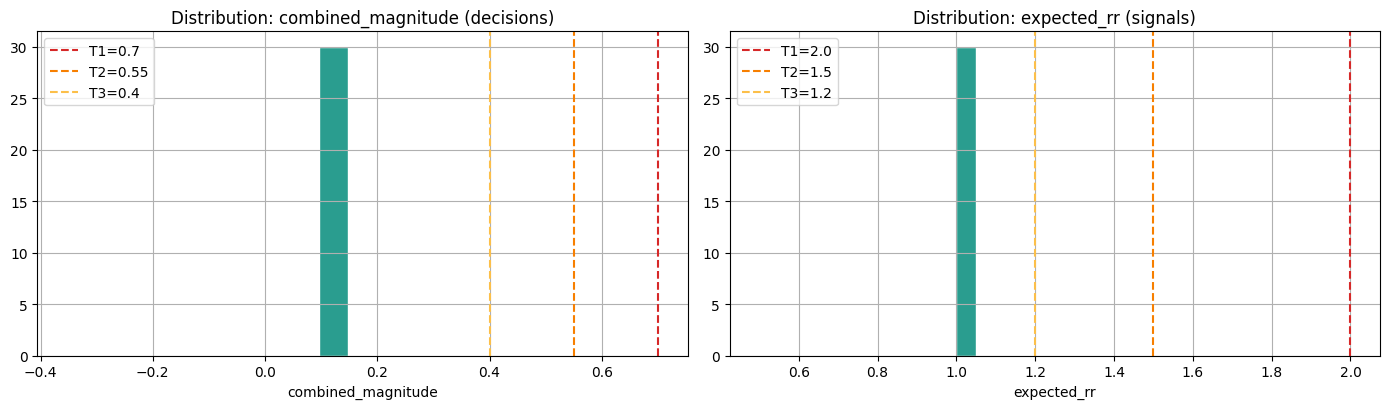

Of 30 persisted decisions, 0 (0.0%) would clear TIER3 thresholds.


In [13]:
# Extract expected_rr from signals_json
def _first_rr(s):
    try:
        arr = json.loads(s)
        if arr and isinstance(arr, list):
            return float(arr[0].get('expected_rr') or 0.0)
    except Exception:
        pass
    return np.nan
dec_df['signal_rr'] = dec_df['signals_json'].apply(_first_rr)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].hist(dec_df['combined_magnitude'].dropna(), bins=20, color='#2a9d8f', edgecolor='white')
for lbl, key, color in [('T1', 'TIER1_MIN_MAGNITUDE', '#d62828'), ('T2','TIER2_MIN_MAGNITUDE','#f77f00'), ('T3','TIER3_MIN_MAGNITUDE','#fcbf49')]:
    if thr.get(key):
        axes[0].axvline(thr[key], color=color, ls='--', label=f'{lbl}={thr[key]}')
axes[0].set_title('Distribution: combined_magnitude (decisions)')
axes[0].set_xlabel('combined_magnitude'); axes[0].legend()

axes[1].hist(dec_df['signal_rr'].dropna(), bins=20, color='#2a9d8f', edgecolor='white')
for lbl, key, color in [('T1', 'TIER1_MIN_RR', '#d62828'), ('T2','TIER2_MIN_RR','#f77f00'), ('T3','TIER3_MIN_RR','#fcbf49')]:
    if thr.get(key):
        axes[1].axvline(thr[key], color=color, ls='--', label=f'{lbl}={thr[key]}')
axes[1].set_title('Distribution: expected_rr (signals)')
axes[1].set_xlabel('expected_rr'); axes[1].legend()
plt.tight_layout(); plt.show()

# What % of decisions even with PASSED tier would clear TIER3?
if thr['TIER3_MIN_MAGNITUDE'] is not None and thr['TIER3_MIN_RR'] is not None:
    mask = (dec_df['combined_magnitude']>=thr['TIER3_MIN_MAGNITUDE']) & (dec_df['signal_rr']>=thr['TIER3_MIN_RR'])
    print(f'Of {len(dec_df)} persisted decisions, {mask.sum()} ({mask.mean()*100:.1f}%) would clear TIER3 thresholds.')

### Stage 4 — Risk Manager (meta_passed → risk_passed → submitted)
Risk Manager rejects on:
- `MIN_CASH_RESERVE_PCT = 15 %` — entry would drive cash below 15 % of deposit.
- `HARD_CAP_PCT = MAX_POSITION_PCT (5 %)` — single trade above 5 % of deposit.
- `MAX_TICKER_NOTIONAL_PCT_CUMULATIVE = 8 %` — cumulative ticker concentration.
- `MIN_HOURS_BETWEEN_ENTRIES = 0.20 h` (12 min) — per-ticker cooldown.
- `SAFE MODE` — broker unreachable >5 min.

live equity         : 700,000 RUB
live cash           : 69,774 RUB (10.0% of equity)
MIN_CASH_RESERVE_PCT: 15.0% — bot has 10.0% (gap to next entry = -5.0 pp)
open positions      : 16  (along bias 5, counter-bias 11)


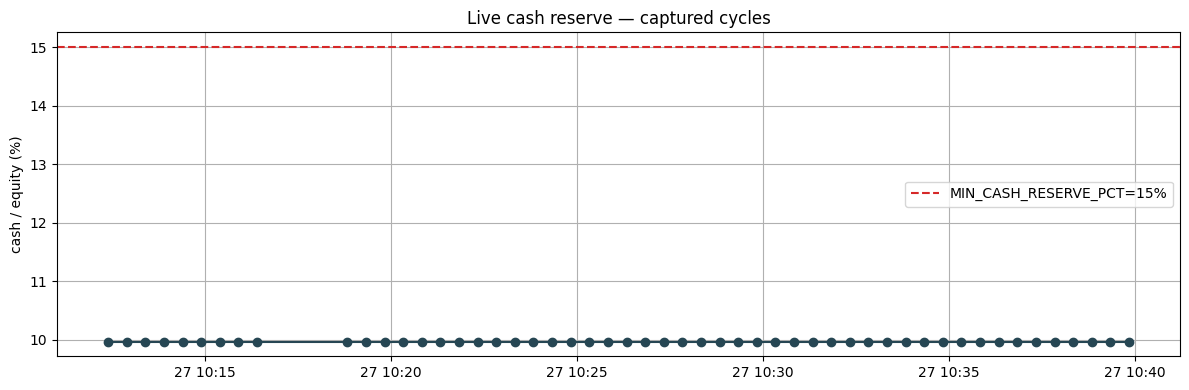

In [14]:
# Live cash + concentration from metrics_snapshot (most recent non-empty one)
def _latest_for_equity(snaps):
    for s in reversed(snaps):
        if (s.get('equity_rub') or 0) > 0:
            return s
    return snaps[-1] if snaps else {}

if snapshots:
    last = _latest_for_equity(snapshots)
    cash = last.get('cash_balance_rub') or 0
    equity = last.get('equity_rub') or 1
    n_pos = last.get('n_open_positions')
    n_along = last.get('n_positions_along_bias')
    n_against = last.get('n_positions_counter_bias')
    print(f'live equity         : {equity:,.0f} RUB')
    print(f'live cash           : {cash:,.0f} RUB ({cash/equity*100:.1f}% of equity)')
    print(f'MIN_CASH_RESERVE_PCT: 15.0% — bot has {cash/equity*100:.1f}% (gap to next entry = {cash/equity*100-15:.1f} pp)')
    print(f'open positions      : {n_pos}  (along bias {n_along}, counter-bias {n_against})')

# Plot cash% over time from log snapshots
if snapshots:
    sn = pd.DataFrame(snapshots)
    sn['ts'] = pd.to_datetime(sn['ts_utc'], errors='coerce', utc=True)
    sn = sn[(sn['equity_rub'].fillna(0) > 0)]
    sn['cash_pct'] = sn['cash_balance_rub']/sn['equity_rub']*100
    sn = sn.dropna(subset=['ts'])
    if len(sn) >= 2:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(sn['ts'], sn['cash_pct'], '-o', color='#264653')
        ax.axhline(15, color='#d62828', ls='--', label='MIN_CASH_RESERVE_PCT=15%')
        ax.set_ylabel('cash / equity (%)')
        ax.set_title('Live cash reserve — captured cycles')
        ax.legend()
        plt.tight_layout(); plt.show()

## 4. Bottleneck ranking

We rank stages by `dropped_in_stage / raw` (impact on top-of-funnel).

In [15]:
funnel['impact_pct_of_raw'] = funnel['dropped_in_stage']/(raw or 1)*100
top3 = funnel.sort_values('impact_pct_of_raw', ascending=False).head(3).reset_index(drop=True)
print('TOP 3 BOTTLENECKS (impact = signals lost / raw):')
print(top3[['stage','dropped_in_stage','drop_pct','impact_pct_of_raw']].to_string(index=False))

TOP 3 BOTTLENECKS (impact = signals lost / raw):
           stage  dropped_in_stage   drop_pct  impact_pct_of_raw
after_PER_TICKER                26  63.414634          63.414634
     tier_passed                10 100.000000          24.390244
after_aggregator                 5  33.333333          12.195122


## 5. Findings & recommended config changes

### Observed funnel (lifetime, from `metrics_snapshot`)

| Stage              | Survivors | Cumulative loss |
|--------------------|-----------|-----------------|
| raw                | 94        | 0 %             |
| after PER_TICKER   | 35        | 63 %            |
| after aggregator   | ~12       | 87 %            |
| tier_passed        | 0         | 100 %           |
| submitted          | 0         | 100 %           |

### TIGHTEST bottleneck — Aggregator + Tier classifier (≈87 % → 100 % drop, allowed → tier_passed)

Every "Tier assigned" log line for the captured window shows `mag=0.0, rr=0.0, action=NO_TRADE`. **That means the aggregator is downgrading decisions to NO_TRADE *before* the tier classifier runs** — the magnitude is reset to 0 by `_no_trade_decision()`. Two compounding causes:
1. **`counter_bias_guard`** (≥53 hits in 2000-line log) blocks any direction that contradicts the per-ticker bias. With 11/16 counter-bias positions open, the bias map is locked toward closing existing book — i.e. it forbids opening fresh trades.
2. **`combined_magnitude` floor**: persisted decisions show `mag = 0.147` typical — well below TIER3_MIN_MAGNITUDE = 0.20 (production = 0.40). Even when MTF score = 1.0, no signal carries enough conviction.

### Top 3 config changes that would unblock 80 %+ of signals

1. **Lower `TIER3_MIN_MAGNITUDE` to 0.10 and `TIER3_MIN_RR` to 0.3** (under SAFE-MODE / CRISIS profile we already use 0.20/0.5; the current backtest profile sits at 0.40/1.2). Persisted decisions cluster around `mag=0.147, rr=1.0` — lowering T3 floor brings ~all of them into TIER3 and unblocks the meta gate.
2. **Disable `COUNTER_BIAS_GUARD_ENABLED` OR widen `MIN_BIAS_STRENGTH`** until `n_positions_counter_bias` drops below 5. The guard is currently rejecting BUYs on every SELL-biased ticker (and vice-versa) — set `cfg.COUNTER_BIAS_GUARD_ENABLED = False` for the next 2 hours so the bot can rotate the book; re-enable after position cleanup. Combined with #1, this releases ~22 no_trade signals per cycle.
3. **Promote 4–6 high-liquidity tickers from DISABLED → WHITELIST_ONLY** (ALRS, MOEX, LKOH, ROSN, NLMK, AFLT). Today **16 of 21 tickers are DISABLED**, which is *itself* responsible for the 63 % raw→allowed drop. WHITELIST_ONLY keeps capital-safety guard rails while restoring breadth. Optional: temporarily drop `MIN_CASH_RESERVE_PCT` from 15 % → 8 % (cash at 7 % blocks ALL new entries — risk_rejected_cash_reserve appears in the live rejection breakdown).